# Pattern Recognition MIDTERM Project: Predicting Sleep Disorders

**Objective:** This project applies pattern recognition algorithms to classify sleep disorders (None, Insomnia, Sleep Apnea). To ensure robustness, models are trained and evaluated across two distinct datasets: one focusing on lifestyle habits and another on diagnostic medical metrics.

## 1. Environment Setup

In [1]:
# 1. Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 4. Machine Learning Algorithms & Evaluation
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Dataset 1: Sleep Health and Lifestyle Dataset

### Step 1: Data Collection (Dataset 1)

In [2]:
# Load the dataset
df1 = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Drop the 'Person ID' column because it is just a row number and has no mathematical value
df1 = df1.drop('Person ID', axis=1)

# Display the first 5 rows to ensure it loaded correctly
display(df1.head())

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


### Step 2: Data Preprocessing (Dataset 1)

In [3]:
# Split the 'Blood Pressure' string into two new columns
df1[['Systolic', 'Diastolic']] = df1['Blood Pressure'].str.split('/', expand=True)

# Convert the new columns from text to integers
df1['Systolic'] = df1['Systolic'].astype(int)
df1['Diastolic'] = df1['Diastolic'].astype(int)

# Drop the original 'Blood Pressure' column since we no longer need it
df1 = df1.drop('Blood Pressure', axis=1)

print("Blood Pressure successfully split into Systolic and Diastolic!")

display(df1.head(5))

Blood Pressure successfully split into Systolic and Diastolic!


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90


In [4]:
# 1. Encode the Target Variable (Sleep Disorder)

df1['Sleep Disorder'] = df1['Sleep Disorder'].fillna('None')

disorder_mapping = {'None': 0, 'Insomnia': 1, 'Sleep Apnea': 2}

df1['Sleep Disorder'] = df1['Sleep Disorder'].map(disorder_mapping)

# 2. Encode Binary/Ordinal text columns
df1['Gender'] = df1['Gender'].map({'Male': 0, 'Female': 1})

df1['BMI Category'] = df1['BMI Category'].replace('Normal Weight', 'Normal')
df1['BMI Category'] = df1['BMI Category'].map({'Normal': 0, 'Overweight': 1, 'Obese': 2})

# 3. One-Hot Encode 'Occupation'
df1 = pd.get_dummies(df1, columns=['Occupation'], drop_first=True)
print("Categorical encoding complete!")

display(df1.head(10))

Categorical encoding complete!


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,0,27,6.1,6,42,6,1,77,4200,0,...,False,False,False,False,False,False,False,False,True,False
1,0,28,6.2,6,60,8,0,75,10000,0,...,True,False,False,False,False,False,False,False,False,False
2,0,28,6.2,6,60,8,0,75,10000,0,...,True,False,False,False,False,False,False,False,False,False
3,0,28,5.9,4,30,8,2,85,3000,2,...,False,False,False,False,False,True,False,False,False,False
4,0,28,5.9,4,30,8,2,85,3000,2,...,False,False,False,False,False,True,False,False,False,False
5,0,28,5.9,4,30,8,2,85,3000,1,...,False,False,False,False,False,False,False,False,True,False
6,0,29,6.3,6,40,7,2,82,3500,1,...,False,False,False,False,False,False,False,False,False,True
7,0,29,7.8,7,75,6,0,70,8000,0,...,True,False,False,False,False,False,False,False,False,False
8,0,29,7.8,7,75,6,0,70,8000,0,...,True,False,False,False,False,False,False,False,False,False
9,0,29,7.8,7,75,6,0,70,8000,0,...,True,False,False,False,False,False,False,False,False,False


In [5]:
# Feature Scaling (Standardization)

# Separate the Target (y) from the Features (X)
X = df1.drop('Sleep Disorder', axis=1)
y = df1['Sleep Disorder']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert back to a DataFrame just so it's easy to read
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Data successfully scaled! Preprocessing for Dataset 1 is complete.")
display(X_scaled_df.head())

Data successfully scaled! Preprocessing for Dataset 1 is complete.


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Systolic,...,Occupation_Doctor,Occupation_Engineer,Occupation_Lawyer,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher
0,-0.989361,-1.753096,-1.298887,-1.098280,-0.825418,0.347021,1.004126,1.654719,-1.619584,-0.330002,...,-0.484070,-0.45008,-0.379119,-0.051778,-0.492468,-0.073324,-0.305888,-0.103975,9.617692,-0.346064
1,-0.989361,-1.637643,-1.173036,-1.098280,0.039844,1.475592,-0.818899,1.170474,1.970077,-0.459239,...,2.065818,-0.45008,-0.379119,-0.051778,-0.492468,-0.073324,-0.305888,-0.103975,-0.103975,-0.346064
2,-0.989361,-1.637643,-1.173036,-1.098280,0.039844,1.475592,-0.818899,1.170474,1.970077,-0.459239,...,2.065818,-0.45008,-0.379119,-0.051778,-0.492468,-0.073324,-0.305888,-0.103975,-0.103975,-0.346064
3,-0.989361,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.827150,3.591698,-2.362273,1.479309,...,-0.484070,-0.45008,-0.379119,-0.051778,-0.492468,13.638182,-0.305888,-0.103975,-0.103975,-0.346064
4,-0.989361,-1.637643,-1.550588,-2.771424,-1.402260,1.475592,2.827150,3.591698,-2.362273,1.479309,...,-0.484070,-0.45008,-0.379119,-0.051778,-0.492468,13.638182,-0.305888,-0.103975,-0.103975,-0.346064


### Step 3: Feature Selection (Dataset 1)

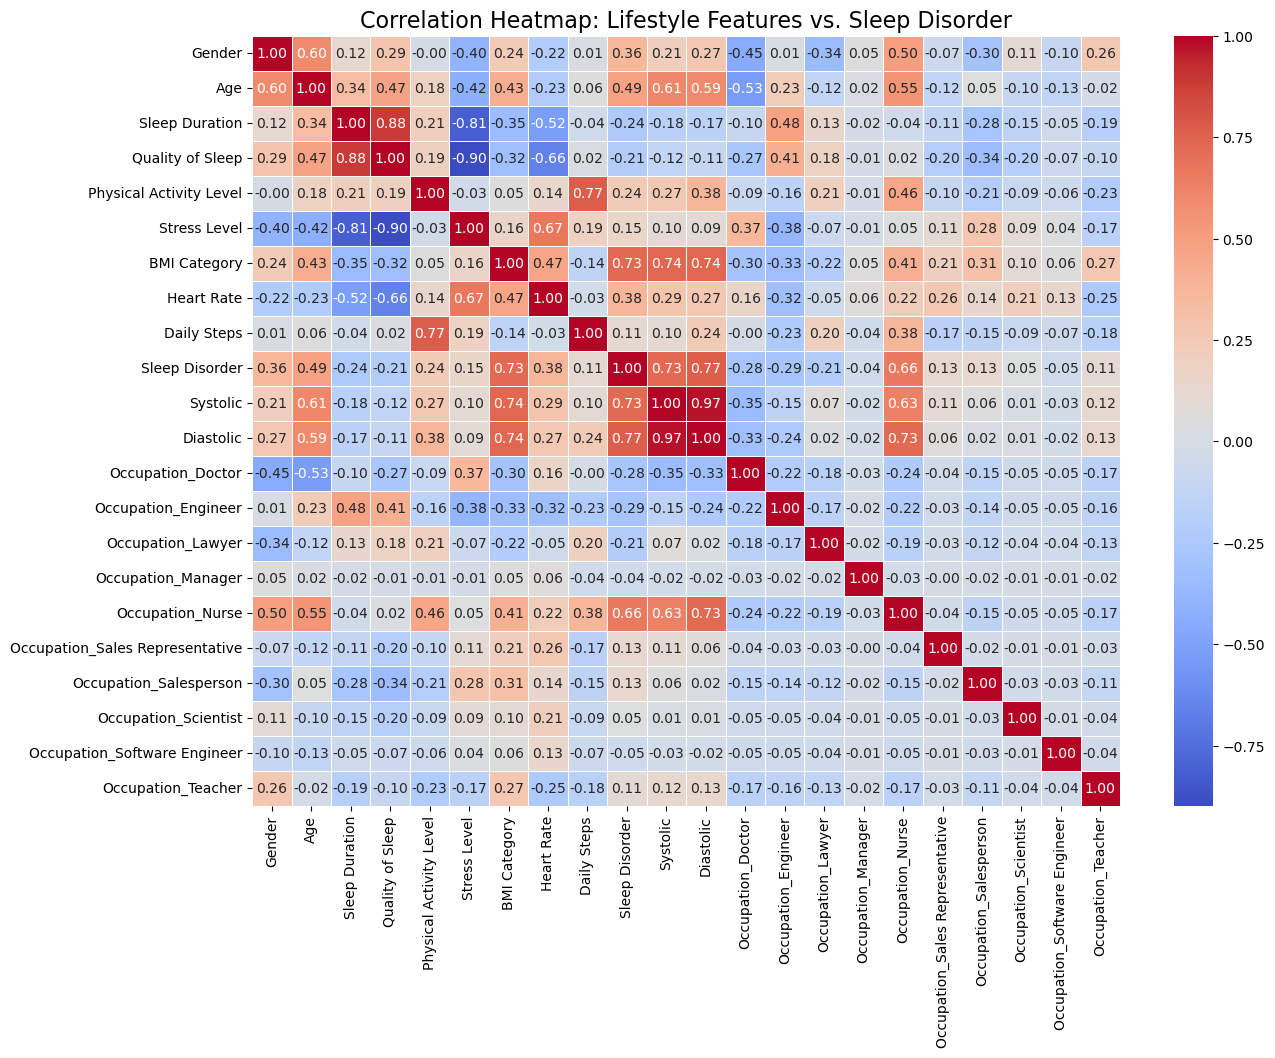

--- Correlation with Sleep Disorder ---
Sleep Disorder                     1.000000
Diastolic                          0.768796
BMI Category                       0.732479
Systolic                           0.730103
Occupation_Nurse                   0.664386
Age                                0.487832
Heart Rate                         0.384343
Gender                             0.362591
Physical Activity Level            0.236560
Stress Level                       0.151893
Occupation_Salesperson             0.130982
Occupation_Sales Representative    0.125043
Daily Steps                        0.112053
Occupation_Teacher                 0.108006
Occupation_Scientist               0.048547
Occupation_Manager                -0.039949
Occupation_Software Engineer      -0.048030
Occupation_Lawyer                 -0.212591
Quality of Sleep                  -0.213003
Sleep Duration                    -0.239109
Occupation_Doctor                 -0.280605
Occupation_Engineer               -0

In [6]:
# Calculate the correlation matrix for all features in Dataset A
corr_matrix = df1.corr()

# Set up the matplotlib figure size
plt.figure(figsize=(14, 10))

# Draw the heatmap using seaborn
# annot=True prints the exact correlation numbers inside the boxes
# cmap='coolwarm' makes strong positive correlations red, and strong negative ones blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Lifestyle Features vs. Sleep Disorder', fontsize=16)
plt.show()

# Print a sorted list to easily see the top predictors for the target variable
print("--- Correlation with Sleep Disorder ---")
print(corr_matrix['Sleep Disorder'].sort_values(ascending=False))

In [7]:
# List of columns with very low correlation to 'Sleep Disorder' (between -0.15 and 0.15)
columns_to_drop = [
    'Daily Steps', 
    'Stress Level', 
    'Occupation_Salesperson', 
    'Occupation_Sales Representative', 
    'Occupation_Teacher', 
    'Occupation_Scientist', 
    'Occupation_Manager', 
    'Occupation_Software Engineer'
]

# Drop these columns from our scaled features dataset
X_selected = X_scaled_df.drop(columns=columns_to_drop)

print(f"Original number of features: {X_scaled_df.shape[1]}")
print(f"New number of features after selection: {X_selected.shape[1]}")

Original number of features: 21
New number of features after selection: 13


In [8]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.20, random_state=13)

print(f"Training Data Shape: {X_train.shape} (80%)")
print(f"Testing Data Shape: {X_test.shape} (20%)")
print("Data successfully split and ready for the algorithms!")

Training Data Shape: (299, 13) (80%)
Testing Data Shape: (75, 13) (20%)
Data successfully split and ready for the algorithms!


### Step 4: Pattern Classification (Dataset A)

In [9]:
# Initialize the three algorithms
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=13),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=13)
}

# Loop through each model, train it, and evaluate it
for name, model in models.items():
    print(f"================ {name} ================")
    
    # 1. Train the model using the 80% training data
    model.fit(X_train, y_train)
    
    # 2. Test the model by making predictions on the 20% unseen data
    y_pred = model.predict(X_test)
    
    # 3. Calculate and print the metrics
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy * 100:.2f}%\n")
    
    print("Classification Report:")
    # target_names helps map the 0, 1, 2 back to the actual text words for readability
    print(classification_report(y_test, y_pred, target_names=['None', 'Insomnia', 'Sleep Apnea']))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

================ Logistic Regression ================
Accuracy: 90.67%

Classification Report:
              precision    recall  f1-score   support

        None       0.95      0.93      0.94        44
    Insomnia       0.89      0.85      0.87        20
 Sleep Apnea       0.77      0.91      0.83        11

    accuracy                           0.91        75
   macro avg       0.87      0.90      0.88        75
weighted avg       0.91      0.91      0.91        75

Confusion Matrix:
[[41  2  1]
 [ 1 17  2]
 [ 1  0 10]]


================ k-Nearest Neighbors ================
Accuracy: 92.00%

Classification Report:
              precision    recall  f1-score   support

        None       0.95      0.95      0.95        44
    Insomnia       0.89      0.85      0.87        20
 Sleep Apnea       0.83      0.91      0.87        11

    accuracy                           0.92        75
   macro avg       0.89      0.90      0.90        75
weighted avg       0.92      0.92      0.92   

## 3. Dataset 2: Sleep Disorder Diagnostic

*This section analyzes clinical and physiological metrics (e.g., AHI Score, Oxygen Saturation) to predict sleep health.*

### Step 1: Data Collection (Dataset 2)

In [10]:
# Load the second dataset
df2 = pd.read_csv('sleep_disorder_dataset.csv')

# Drop the columns that are not useful
columns_to_drop_b = ['Patient_ID', 'OCR_Extracted_Text', 'Diagnosis_Confirmed']
df2 = df2.drop(columns=columns_to_drop_b, axis=1)

print("Dataset B loaded and non-numerical columns dropped!")
display(df2.head())

Dataset B loaded and non-numerical columns dropped!


,Age,Gender,Sleep_Disorder_Type,AHI_Score,SaO2_Level
0,54,Female,Restless Leg Syndrome,44.11,77.59
1,17,Female,Restless Leg Syndrome,33.55,76.22
2,74,Male,Insomnia,12.91,89.53
3,63,Male,Restless Leg Syndrome,33.73,85.65
4,23,Female,Insomnia,14.84,88.70



### Step 2: Data Preprocessing (Dataset 2)

In [11]:
# 1. Encode the Target Variable Manually
# We align Insomnia (1) and Apnea (2) with Dataset A for consistency, 
# and add the new disorders as 3 and 4.
disorder_mapping_b = {
    'No Disorder': 0,
    'Insomnia': 1,
    'Obstructive Sleep Apnea': 2,
    'Narcolepsy': 3,
    'Restless Leg Syndrome': 4
}

# Apply the mapping
df2['Sleep_Disorder_Type'] = df2['Sleep_Disorder_Type'].map(disorder_mapping_b)

# Print to confirm
print("--- Dataset 2 Disorder Mapping ---")
for text, num in disorder_mapping_b.items():
    print(f"{num} = {text}")
# 2. Encode Gender
# Checking if there are any trailing spaces just in case, then mapping
df2['Gender'] = df2['Gender'].str.strip() 
df2['Gender'] = df2['Gender'].map({'Male': 0, 'Female': 1})

# 3. Separate Features (X) and Target (y)
X2 = df2.drop('Sleep_Disorder_Type', axis=1)
y2 = df2['Sleep_Disorder_Type']

# 4. Feature Scaling
scaler_b = StandardScaler()
X2_scaled = scaler_b.fit_transform(X2)

# Convert back to DataFrame for easy viewing
X2_scaled_df = pd.DataFrame(X2_scaled, columns=X2.columns)

print("\nDataset B successfully encoded and scaled!")
display(X2_scaled_df.head())

--- Dataset 2 Disorder Mapping ---
0 = No Disorder
1 = Insomnia
2 = Obstructive Sleep Apnea
3 = Narcolepsy
4 = Restless Leg Syndrome

Dataset B successfully encoded and scaled!


,Age,Gender,AHI_Score,SaO2_Level
0,0.596513,1.016130,1.284761,-1.378650
1,-1.037164,1.016130,0.547213,-1.569571
2,1.479581,-0.984126,-0.894357,0.285286
3,0.993893,-0.984126,0.559785,-0.255424
4,-0.772243,1.016130,-0.759559,0.169618


### Step 3: Feature Selection (Dataset 2 Heatmap)

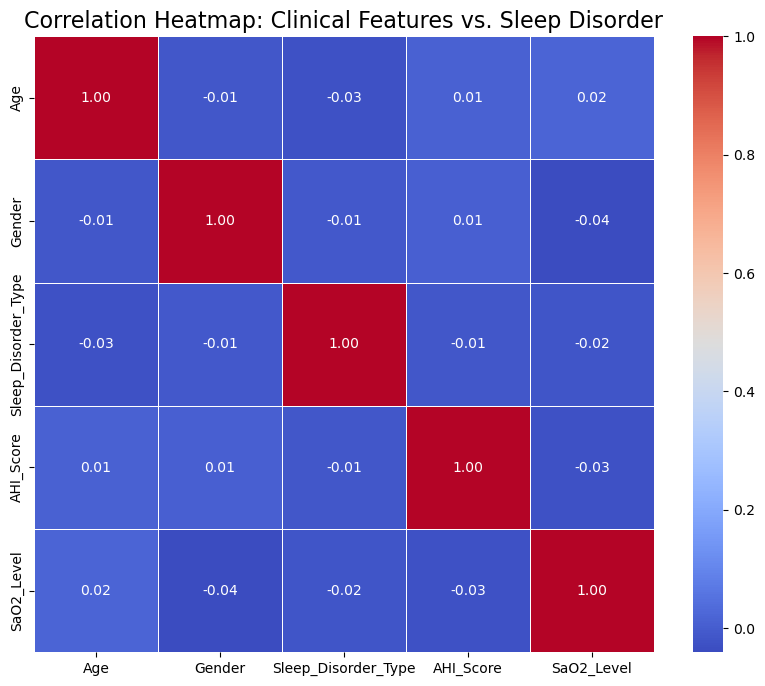

--- Correlation with Sleep_Disorder_Type ---
Sleep_Disorder_Type    1.000000
Gender                -0.008763
AHI_Score             -0.012635
SaO2_Level            -0.016938
Age                   -0.027234
Name: Sleep_Disorder_Type, dtype: float64


In [12]:
# Calculate the correlation matrix for all features in Dataset B
corr_matrix_b = df2.corr()

# Set up the matplotlib figure size
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(corr_matrix_b, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Clinical Features vs. Sleep Disorder', fontsize=16)
plt.show()

# Print the sorted list to easily see the top predictors
print("--- Correlation with Sleep_Disorder_Type ---")
print(corr_matrix_b['Sleep_Disorder_Type'].sort_values(ascending=False))

According to the results of correlation heatmap, we understand that we should use non-linear models.

### Step 4: Pattern Classification (Dataset 2)

In [13]:
# 1. Split Dataset 2 into 80% train and 20% test
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_scaled_df, y2, test_size=0.20, random_state=42)

# 2. Initialize the exact same three models
models_b = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# 3. Loop through, train, and evaluate on Dataset B
for name, model in models_b.items():
    print(f"================ {name} ================")
    
    # Train the model
    model.fit(X2_train, y2_train)
    
    # Make predictions
    y2_pred = model.predict(X2_test)
    
    # Calculate accuracy
    accuracy_b = accuracy_score(y2_test, y2_pred)
    print(f"Accuracy: {accuracy_b * 100:.2f}%\n")
    
    print("Classification Report:")
    # We pass the list of disease names we created earlier for a clean report
    target_names_b = ['No Disorder', 'Insomnia', 'Sleep Apnea', 'Narcolepsy', 'Restless Leg']
    print(classification_report(y2_test, y2_pred, target_names=target_names_b, zero_division=0))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y2_test, y2_pred))
    print("\n")

================ Logistic Regression ================
Accuracy: 32.00%

Classification Report:
              precision    recall  f1-score   support

 No Disorder       0.00      0.00      0.00        19
    Insomnia       0.25      0.41      0.31        44
 Sleep Apnea       0.36      0.69      0.47        67
  Narcolepsy       0.00      0.00      0.00        33
Restless Leg       0.00      0.00      0.00        37

    accuracy                           0.32       200
   macro avg       0.12      0.22      0.16       200
weighted avg       0.18      0.32      0.23       200

Confusion Matrix:
[[ 0  6 13  0  0]
 [ 0 18 26  0  0]
 [ 0 21 46  0  0]
 [ 0 13 20  0  0]
 [ 0 15 22  0  0]]


================ k-Nearest Neighbors ================
Accuracy: 19.50%

Classification Report:
              precision    recall  f1-score   support

 No Disorder       0.09      0.11      0.10        19
    Insomnia       0.17      0.30      0.22        44
 Sleep Apnea       0.27      0.19      0.23    